In [ ]:
"""
Wszystkie początkowe wersje modeli miały dokładności bliskie zera. Iteracji było całkiem sporo zeby osiągnąc 
jako taki wynik, więc załączyłam tylko wersje z duzymi zmianami w logice modelu:).
"""

In [ ]:
import spacy
import re
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import normalize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from nltk.util import ngrams
import numpy as np
import matplotlib.pyplot as plt
from joblib import Parallel, delayed #chyba w koncu nie użyłam równoległęgo przetwarzania ale bałam sie usunąć:)
import pickle
import torch
from sentence_transformers import SentenceTransformer, util

Załadowanie danych

In [7]:
with open('train_sho.pkl', 'rb') as f:
    con_sho = pickle.load(f)
with open("train_med.pkl", "rb") as f:
    con_med = pickle.load(f)
with open("train_long.pkl", "rb") as f:
    con_lon = pickle.load(f)

with open('ques_sho.pkl', 'rb') as f:
    ques_sho = pickle.load(f)
with open("ques_med.pkl", "rb") as f:
    ques_med = pickle.load(f)
with open("ques_lon.pkl", "rb") as f:
    ques_lon = pickle.load(f)

with open('ans_sho.pkl', 'rb') as f:
    ans_sho = pickle.load(f)
with open("ans_med.pkl", "rb") as f:
    ans_med = pickle.load(f)
with open("ans_lon.pkl", "rb") as f:
    ans_lon = pickle.load(f)

Model 1. Set of words, Bag of Words, TF-IDF:

    -lematyzacja
    -filtrowanie po artykułach
    -ngramy (dla kontestu)

In [6]:
#model
nlp = spacy.load("pl_core_news_md")

In [ ]:
#Model Vectorisers

#preprocessing
def preprocess(text):
    doc = nlp(re.sub(r"[^\w\s]", "", text.lower())) #dopasuj wszytsko co nie jest literą bądź liczbą
    return " ".join([token.lemma_ for token in doc if not token.is_stop]) #lematyzacja tokenów, usunięcie stopwords

#próbowałam wersje z entites ale obniżała wyniki

# def preprocess(text):
#     doc = nlp(re.sub(r"[^\w\s]", "", text.lower()))
#     lemmas = [token.lemma_ for token in doc if not token.is_stop]
#     entities = [ent.text.lower() for ent in doc.ents if ent.label_ != ""]
#     return " ".join(lemmas + entities)

#n-gram overlap
def ngram_overlap(q, s, n=2): #q-question,  s-sentence
    q_ngrams = set(ngrams(q.split(), n)) #tworzenie setu ngramów
    s_ngrams = set(ngrams(s.split(), n))
    if not q_ngrams or not s_ngrams:
        return 0
    return len(q_ngrams & s_ngrams) / len(q_ngrams)  #długość części wspólnej / długość question

#score sentence
def score_sentence(question, sentence, vectorizer, a = 0.9):
    question_proc = preprocess(question) #preprocessing
    sentence_proc = preprocess(sentence)

    matrix = normalize(vectorizer.transform([question_proc, sentence_proc])) #macierz znormalizowanych wektorów
    cos_sim = cosine_similarity(matrix[0], matrix[1])[0][0] #podobieństwo cosinusowe zdań: 1 - takie same, 0 - prostopadłe
    ngram_sim = ngram_overlap(question_proc, sentence_proc, n=2) #podobieństwo ngramowe: ratio nakładjących się ngramów
    return a * cos_sim + (1-a) * ngram_sim

#train model
def train_model(contexts, vectorizer):
    all_sentences = []
    processed_articles = []

    for article in contexts:
        sentences = [sent.text.strip() for sent in nlp(article).sents] #lista zdan z artykułu - zdania bez białych znaków na koncach lini
        all_sentences.append(sentences)
        processed_articles.append(preprocess(article))

    vectorizer.fit(processed_articles) #preproccesing i nauka vectoriser na context
    return all_sentences, processed_articles

#select best article
def select_best_article(question, processed_articles, vectorizer):
    question_proc = preprocess(question)
    
    matrix = normalize(vectorizer.transform([question_proc] + processed_articles)) 
    sims = cosine_similarity(matrix[0], matrix[1:])[0] #podobieństwo wektorowe
    return int(np.argmax(sims)) #indeks najlepszego artykułu

#wybór najleszego zdania
def ask_question(question, all_sentences, processed_articles, vectorizer, a: float):
    best_article_idx = select_best_article(question, processed_articles, vectorizer) #index najlepszego artykułu
    candidate_sentences = all_sentences[best_article_idx] #zdania z najlepszego artykułu
    scores = [score_sentence(question, s, vectorizer, a) for s in candidate_sentences] #score podonieństwa zdań
    best_idx = int(np.argmax(scores)) #indeks najlepszego zdania
    return candidate_sentences[best_idx] #najlepsze zdanie

# similarity check
def is_similar(pred, true, vectorizer, threshold=0.9):
    pred_proc = preprocess(pred)
    true_proc = preprocess(true)
    vecs = normalize(vectorizer.transform([pred_proc, true_proc]))  # normalizacja
    similarity = cosine_similarity(vecs[0], vecs[1])[0][0] #porównanie podonieństwa
    return similarity >= threshold #true/false

#ostateczne wywołanie
def run_model(vectorizer, context, questions, answers, a: float):
    all_sentences, processed_articles = train_model(context, vectorizer) #trenowanie modelu - lepiej by było zrobić to osobno a potem dopasowywać prametry

    ans_score = 0
    art_score = 0
    ok_len = [] #lista długości dobrych predictions (pod warunkiem dobrze wybranego artykułu)
    notok_len = [] #lista długości złych predictions (pod warunkiem dobrze wybranego artykułu)

    for i in range(len(questions)): #dla każdego pytania
        best_article_idx = select_best_article(questions[i], processed_articles, vectorizer) #indeks najlepszego artykułu
        candidate_sentences = all_sentences[best_article_idx] #zdania z najlepszego artykułu

        article_correct = answers[i] in candidate_sentences #czy zdanie znajduje sie w wybranym artykule
        art_score += int(article_correct) #dobrze wybrane artykuły

        pred_ans = ask_question(questions[i], all_sentences, processed_articles, vectorizer, a) #najlepsze zdanie
        answer_correct = is_similar(pred_ans, answers[i], vectorizer, 0.9) #czy pred dobra
        ans_score += int(answer_correct) #score dobrych pred

        if article_correct: #jeżeli dobrze wybrany artykuł
            q_len = len(questions[i]) 
            a_len = len(answers[i])
            if answer_correct:
                ok_len.append((q_len, a_len)) #lista długości poprawnych q/a
            else:
                notok_len.append((q_len, a_len)) #lista błędnych

    acc_ans = ans_score / len(questions) #final score
    acc_art = art_score / len(questions)

    return (acc_ans, acc_art, ok_len, notok_len)

Set of Words

In [ ]:
#Set of Words
a_list = np.arange(0, 1.1, 0.1) #parametr a: [0.1,1] co 0.1

set_sho, set_med, set_lon = [], [], []

#testowanie parametru a
for a in a_list:
    (acc_ans, acc_art, ok_len, notok_len) = run_model(CountVectorizer(binary=True), con_sho, ques_sho, ans_sho, a)
    set_sho.append((acc_ans, acc_art))
    (acc_ans, acc_art, ok_len, notok_len) = run_model(CountVectorizer(binary=True), con_med, ques_med, ans_med, a)
    set_med.append((acc_ans, acc_art))
    (acc_ans, acc_art, ok_len, notok_len) = run_model(CountVectorizer(binary=True), con_lon, ques_lon, ans_lon, a)
    set_lon.append((acc_ans, acc_art))

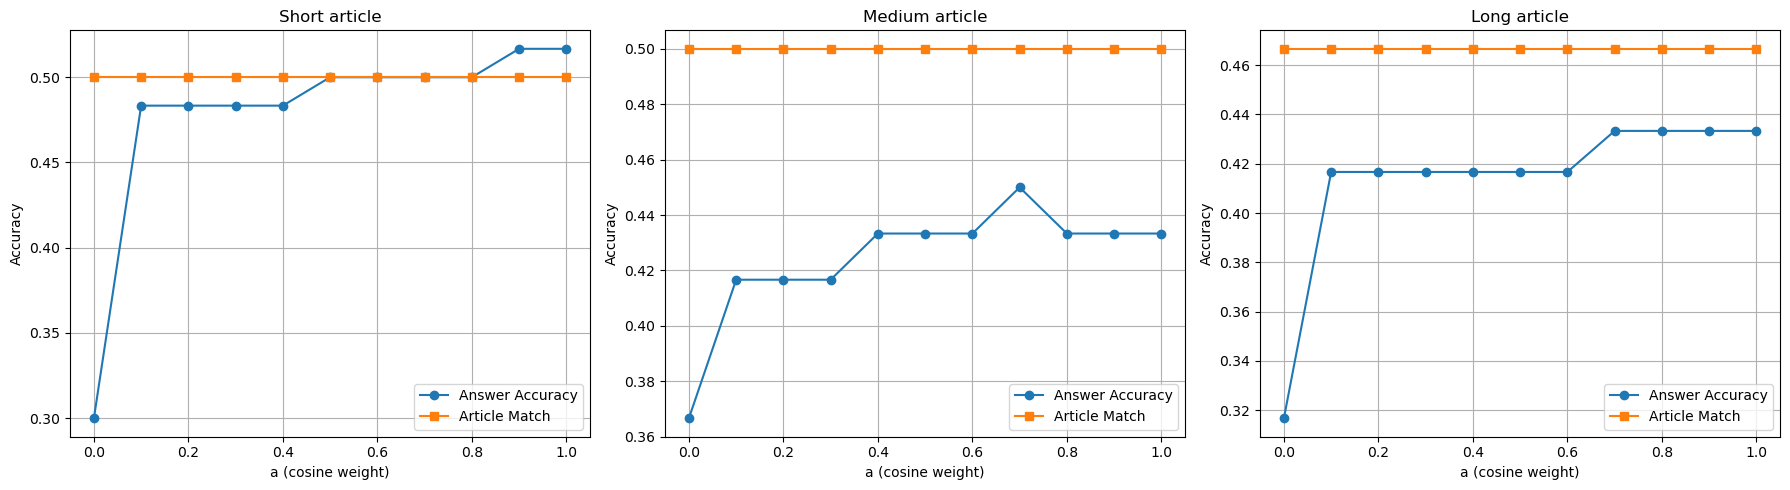

In [ ]:
#wykres accuracies
set_final = [set_sho, set_med, set_lon]  
labels = ['Short', 'Medium', 'Long']    

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  

for i in range(len(set_final)):
    acc_ans = [x[0] for x in set_final[i]]  
    acc_art = [x[1] for x in set_final[i]]  

    ax = axes[i] 

    ax.plot(a_list, acc_ans, label="Answer Accuracy", marker='o')
    ax.plot(a_list, acc_art, label="Article Match", marker='s')

    ax.set_title(f"{labels[i]} article")    
    ax.set_xlabel("a (cosine weight)")   
    ax.set_ylabel("Accuracy")                
    ax.grid(True)
    ax.legend()

plt.tight_layout()  
plt.savefig('set.png', dpi=300, bbox_inches='tight')
plt.show()       

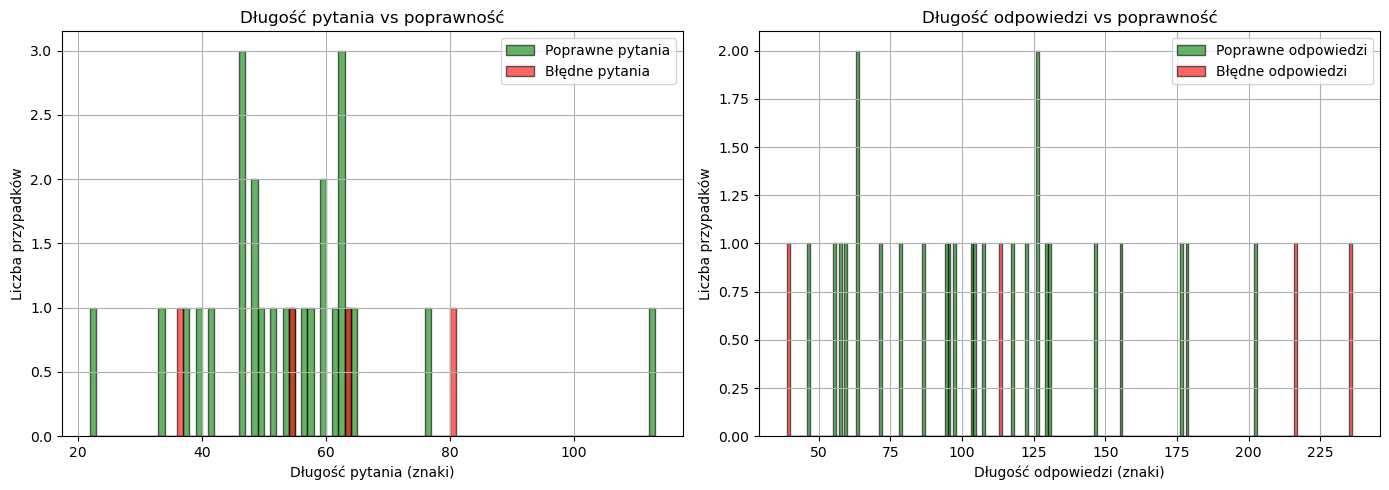

In [ ]:
#wykres długości pyt/odp dla najlepszego modelu
(acc_ans, acc_art, ok_len, notok_len) = run_model(CountVectorizer(binary=True), con_sho, ques_sho, ans_sho, 0.9)
ok_ques = [q for (q,a) in ok_len]
notok_ques = [q for (q,a) in notok_len]

ok_ans = [a for (q,a) in ok_len]
notok_ans = [a for (q,a) in notok_len]
ques_len = ok_ques + notok_ques
ans_len = ok_ans + notok_ans

fig, axs = plt.subplots(1, 2, figsize=(14, 5))  #1 rząd, 2 kolumny

#długość pytań
bins_q = range(min(ques_len), max(ques_len) + 1) #granice przedziałów (bins)
axs[0].hist(ok_ques, bins=bins_q, alpha=0.6, label="Poprawne pytania", color='green', edgecolor='black')
axs[0].hist(notok_ques, bins=bins_q, alpha=0.6, label="Błędne pytania", color='red', edgecolor='black')
axs[0].set_title("Długość pytania vs poprawność")
axs[0].set_xlabel("Długość pytania (znaki)")
axs[0].set_ylabel("Liczba przypadków")
axs[0].legend()
axs[0].grid(True)

#długość odpowiedzi
bins_a = range(min(ans_len), max(ans_len) + 1)
axs[1].hist(ok_ans, bins=bins_a, alpha=0.6, label="Poprawne odpowiedzi", color='green', edgecolor='black')
axs[1].hist(notok_ans, bins=bins_a, alpha=0.6, label="Błędne odpowiedzi", color='red', edgecolor='black')
axs[1].set_title("Długość odpowiedzi vs poprawność")
axs[1].set_xlabel("Długość odpowiedzi (znaki)")
axs[1].set_ylabel("Liczba przypadków")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

Bag of words - analogicznie

In [164]:
#Bag of words

bag_sho = []
bag_med = []
bag_lon = []
for a in a_list:
    bag_sho.append(run_model(CountVectorizer(), con_sho, ques_sho, ans_sho, a))
    bag_med.append(run_model(CountVectorizer(), con_med, ques_med, ans_med, a))
    bag_lon.append(run_model(CountVectorizer(), con_lon, ques_lon, ans_lon, a))

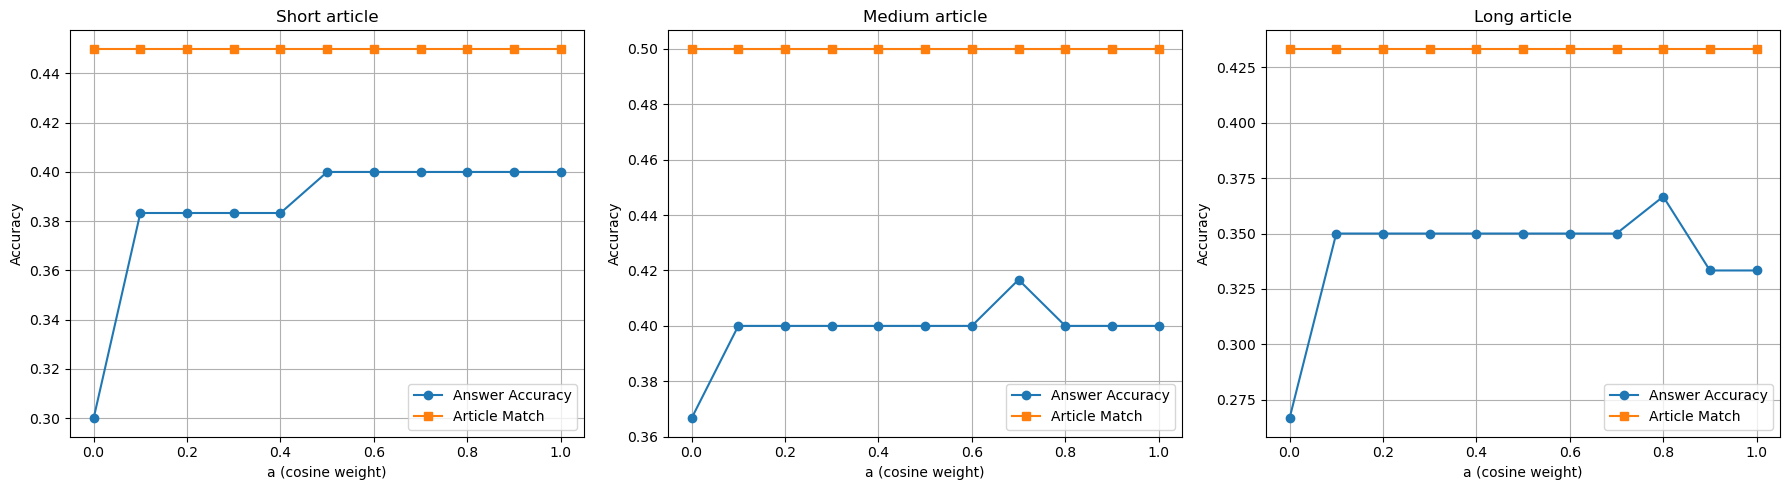

In [ ]:
#wykres accuracies
bag_final = [bag_sho, bag_med, bag_lon]  
labels = ['Short', 'Medium', 'Long']    

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  

for i in range(len(bag_final)):
    acc_ans = [x[0] for x in bag_final[i]]  
    acc_art = [x[1] for x in bag_final[i]]  

    ax = axes[i] 

    ax.plot(a_list, acc_ans, label="Answer Accuracy", marker='o')
    ax.plot(a_list, acc_art, label="Article Match", marker='s')

    ax.set_title(f"{labels[i]} article")    
    ax.set_xlabel("a (cosine weight)")   
    ax.set_ylabel("Accuracy")                
    ax.grid(True)
    ax.legend()

plt.tight_layout()  
plt.savefig('bag.png', dpi=300, bbox_inches='tight')
plt.show()       

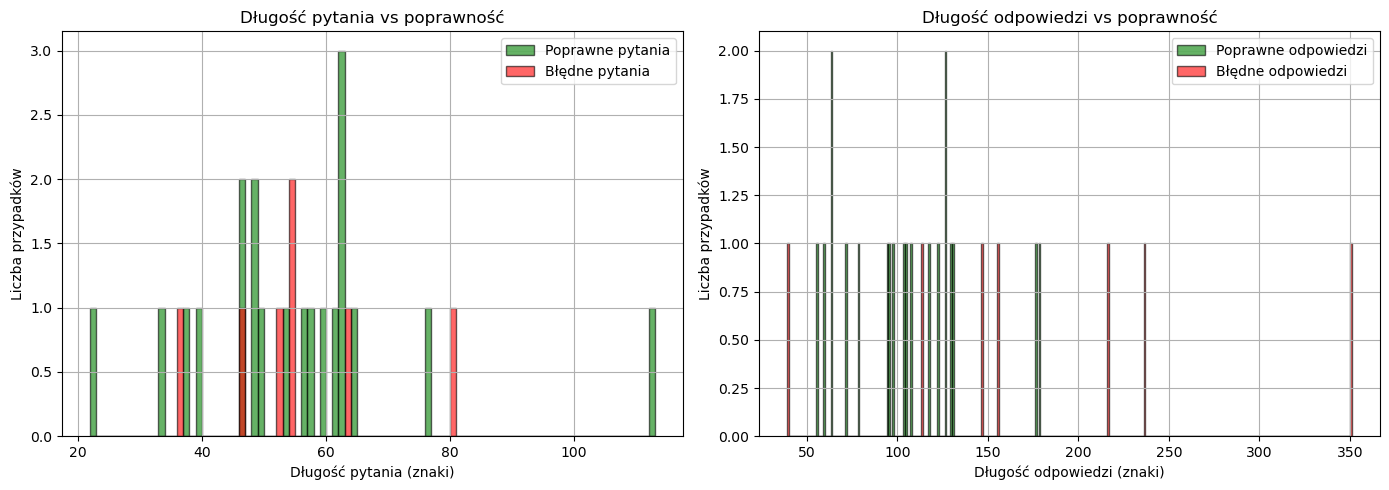

In [ ]:
#wykres długości pyt/odp dla najlepszego modelu
(acc_ans, acc_art, ok_len, notok_len) = run_model(CountVectorizer(), con_sho, ques_sho, ans_sho, 0.9)
ok_ques = [q for (q,a) in ok_len]
notok_ques = [q for (q,a) in notok_len]

ok_ans = [a for (q,a) in ok_len]
notok_ans = [a for (q,a) in notok_len]
ques_len = ok_ques + notok_ques
ans_len = ok_ans + notok_ans

fig, axs = plt.subplots(1, 2, figsize=(14, 5)) 

#długość pytań
bins_q = range(min(ques_len), max(ques_len) + 1)
axs[0].hist(ok_ques, bins=bins_q, alpha=0.6, label="Poprawne pytania", color='green', edgecolor='black')
axs[0].hist(notok_ques, bins=bins_q, alpha=0.6, label="Błędne pytania", color='red', edgecolor='black')
axs[0].set_title("Długość pytania vs poprawność")
axs[0].set_xlabel("Długość pytania (znaki)")
axs[0].set_ylabel("Liczba przypadków")
axs[0].legend()
axs[0].grid(True)

#długość odpowiedzi
bins_a = range(min(ans_len), max(ans_len) + 1)
axs[1].hist(ok_ans, bins=bins_a, alpha=0.6, label="Poprawne odpowiedzi", color='green', edgecolor='black')
axs[1].hist(notok_ans, bins=bins_a, alpha=0.6, label="Błędne odpowiedzi", color='red', edgecolor='black')
axs[1].set_title("Długość odpowiedzi vs poprawność")
axs[1].set_xlabel("Długość odpowiedzi (znaki)")
axs[1].set_ylabel("Liczba przypadków")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

TF-IDF - analogicznie

In [ ]:
#TF-IDF
tf_sho, tf_med, tf_lon = [], [], []

for a in a_list:
    tf_sho.append(run_model(TfidfVectorizer(), con_sho, ques_sho, ans_sho, a))
    tf_med.append(run_model(TfidfVectorizer(), con_med, ques_med, ans_med, a))
    tf_lon.append(run_model(TfidfVectorizer(), con_lon, ques_lon, ans_lon, a))

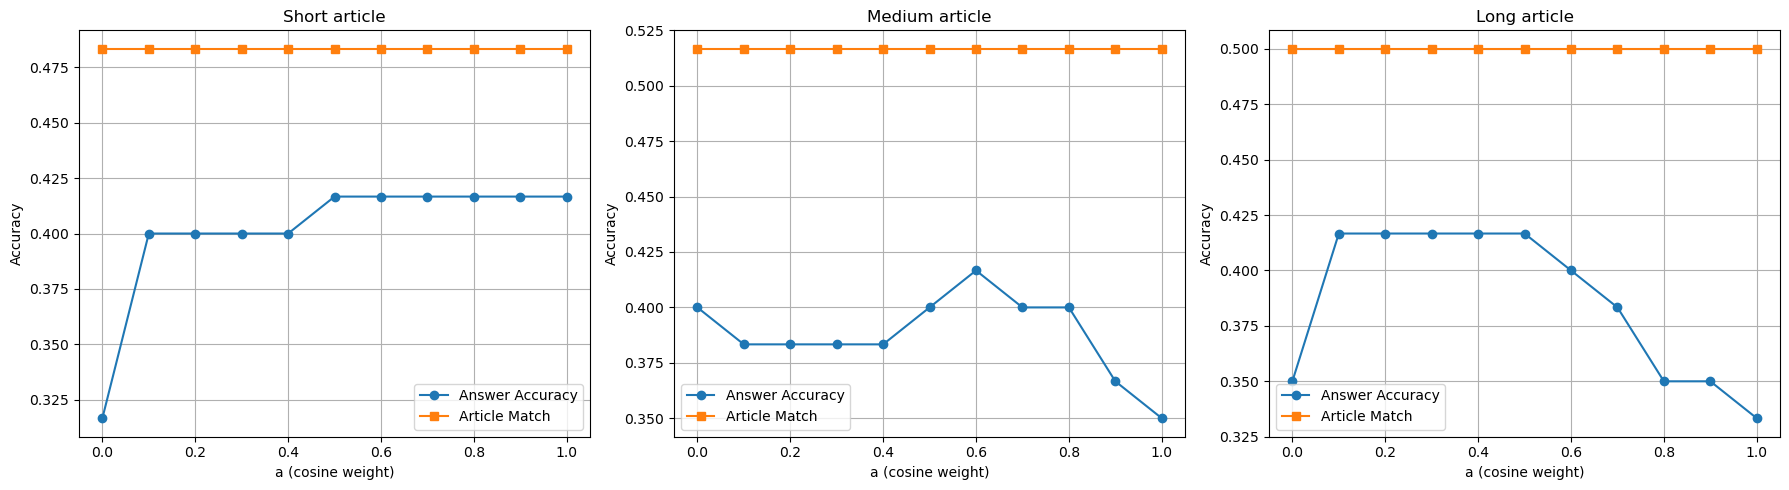

In [ ]:
#wykres accuracies
tf_final = [tf_sho, tf_med, tf_lon]  
labels = ['Short', 'Medium', 'Long']    

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  

for i in range(len(tf_final)):
    acc_ans = [x[0] for x in tf_final[i]]  
    acc_art = [x[1] for x in tf_final[i]]  

    ax = axes[i]  # aktualna oś (subplot)

    ax.plot(a_list, acc_ans, label="Answer Accuracy", marker='o')
    ax.plot(a_list, acc_art, label="Article Match", marker='s')

    ax.set_title(f"{labels[i]} article")    
    ax.set_xlabel("a (cosine weight)")   
    ax.set_ylabel("Accuracy")                
    ax.grid(True)
    ax.legend()

plt.tight_layout()  
plt.savefig('tf.png', dpi=300, bbox_inches='tight')
plt.show()       

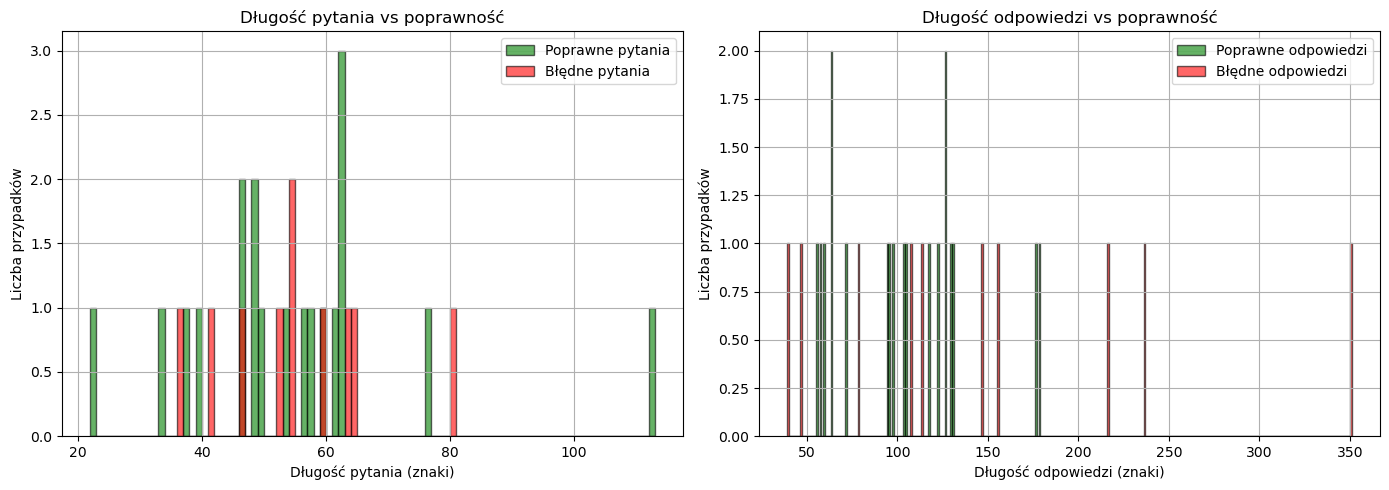

In [ ]:
#wykres długości pyt/odp dla najlepszego modelu
(acc_ans, acc_art, ok_len, notok_len) = run_model(TfidfVectorizer(), con_sho, ques_sho, ans_sho, 0.9)
ok_ques = [q for (q,a) in ok_len]
notok_ques = [q for (q,a) in notok_len]

ok_ans = [a for (q,a) in ok_len]
notok_ans = [a for (q,a) in notok_len]
ques_len = ok_ques + notok_ques
ans_len = ok_ans + notok_ans

fig, axs = plt.subplots(1, 2, figsize=(14, 5))  

#pytania
bins_q = range(min(ques_len), max(ques_len) + 1)
axs[0].hist(ok_ques, bins=bins_q, alpha=0.6, label="Poprawne pytania", color='green', edgecolor='black')
axs[0].hist(notok_ques, bins=bins_q, alpha=0.6, label="Błędne pytania", color='red', edgecolor='black')
axs[0].set_title("Długość pytania vs poprawność")
axs[0].set_xlabel("Długość pytania (znaki)")
axs[0].set_ylabel("Liczba przypadków")
axs[0].legend()
axs[0].grid(True)

#odpowiedzi
bins_a = range(min(ans_len), max(ans_len) + 1)
axs[1].hist(ok_ans, bins=bins_a, alpha=0.6, label="Poprawne odpowiedzi", color='green', edgecolor='black')
axs[1].hist(notok_ans, bins=bins_a, alpha=0.6, label="Błędne odpowiedzi", color='red', edgecolor='black')
axs[1].set_title("Długość odpowiedzi vs poprawność")
axs[1].set_xlabel("Długość odpowiedzi (znaki)")
axs[1].set_ylabel("Liczba przypadków")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

In [ ]:
#tf-idf - dodatkowe parametry; akurat nietrafione, lepiej zrobić grid search

vectoriser = TfidfVectorizer(
    min_df=3, #ignorowanie bardzo rzadkich słów
    max_df=0.9, #ignorowanie bardzo częstych słów (szumu)
    sublinear_tf=True, #liniowe na logatyrmiczne
    max_features=5000 #liczba cech
)
a_list = np.arange(0, 1.1, 0.1)
tf2_sho, tf2_med, tf2_lon = [], [], []

for a in a_list:
    tf2_sho.append(run_model(vectoriser, con_sho, ques_sho, ans_sho, a))
    tf2_med.append(run_model(vectoriser, con_med, ques_med, ans_med, a))
    tf2_lon.append(run_model(vectoriser, con_lon, ques_lon, ans_lon, a))       

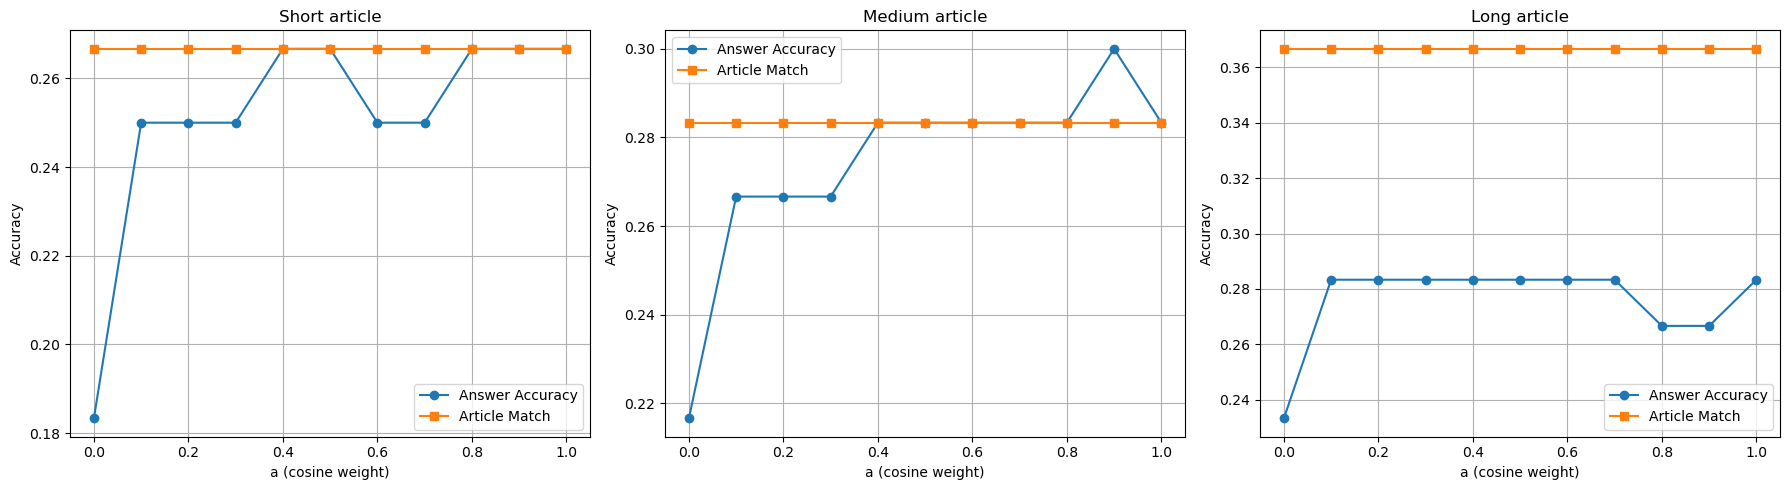

In [ ]:
#wykres accuracies
tf2_final = [tf2_sho, tf2_med, tf2_lon]  
labels = ['Short', 'Medium', 'Long']    

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  

for i in range(len(tf2_final)):
    acc_ans = [x[0] for x in tf2_final[i]]  
    acc_art = [x[1] for x in tf2_final[i]]  

    ax = axes[i] 

    ax.plot(a_list, acc_ans, label="Answer Accuracy", marker='o')
    ax.plot(a_list, acc_art, label="Article Match", marker='s')

    ax.set_title(f"{labels[i]} article")    
    ax.set_xlabel("a (cosine weight)")   
    ax.set_ylabel("Accuracy")                
    ax.grid(True)
    ax.legend()

plt.tight_layout()  
plt.savefig('tf.png', dpi=300, bbox_inches='tight')
plt.show()

Spacy embeddings

In [ ]:
#model spacy embeddings

#preprocessing
def preprocess(text):
    doc = nlp(re.sub(r"[^\w\s]", "", text.lower())) #dopasuj wszytsko co nie jest literą bądź liczbą
    return " ".join([token.lemma_ for token in doc if not token.is_stop]) #lematyzacja tokenów, usunięcie stopwords

#n-gram overlap
def ngram_overlap(q, s, n=2): #q-question,  s-sentence
    q_ngrams = set(ngrams(q.split(), n)) #tworzenie setu ngramów
    s_ngrams = set(ngrams(s.split(), n))
    if not q_ngrams or not s_ngrams:
        return 0
    return len(q_ngrams & s_ngrams) / len(q_ngrams)  #długość części wspólnej / długość question

#score sentence
def score_sentence(question, sentence, a=0.9):
    question_proc = preprocess(question)
    sentence_proc = preprocess(sentence)

    q_vec = nlp(question_proc).vector #spacy embedings dla pyt
    s_vec = nlp(sentence_proc).vector

    if np.linalg.norm(q_vec) == 0 or np.linalg.norm(s_vec) == 0:
        cos_sim = 0 #unikniecie dzielenia przez 0
    else:
        cos_sim = cosine_similarity([q_vec], [s_vec])[0][0] #podobieńswo cosinusowe dla znormalizowanych wektoró

    ngram_sim = ngram_overlap(question_proc, sentence_proc, n=2)
    return a * cos_sim + (1 - a) * ngram_sim

#train model
def train_model(contexts):
    all_sentences = []
    processed_articles = []

    for article in contexts:
        sentences = [sent.text.strip() for sent in nlp(article).sents]
        all_sentences.append(sentences)
        processed_articles.append(preprocess(article))

    return all_sentences, processed_articles


#select best article
def select_best_article(question, processed_articles):
    question_vec = nlp(preprocess(question)).vector #wektory pytań
    article_vecs = [nlp(article).vector for article in processed_articles] #wektory artykułów

    sims = [] #lista podobieństw cos
    for vec in article_vecs: #iteracja po artykułach (zwektoryzowane)
        if np.linalg.norm(question_vec) == 0 or np.linalg.norm(vec) == 0:
            sims.append(0)
        else:
            sims.append(cosine_similarity([question_vec], [vec])[0][0])

    return int(np.argmax(sims))


def ask_question(question, all_sentences, processed_articles, a: float):
    best_article_idx = select_best_article(question, processed_articles)
    candidate_sentences = all_sentences[best_article_idx]
    scores = [score_sentence(question, s, a=a) for s in candidate_sentences]
    best_idx = int(np.argmax(scores))
    return candidate_sentences[best_idx] #najbardziej pasujące zdanie

# similarity check
def is_similar(pred, true, vectorizer=None, threshold=0.8):
    pred_proc = preprocess(pred)
    true_proc = preprocess(true)

    pred_vec = nlp(pred_proc).vector
    true_vec = nlp(true_proc).vector

    if np.linalg.norm(pred_vec) == 0 or np.linalg.norm(true_vec) == 0:
        similarity = 0
    else:
        similarity = cosine_similarity([pred_vec], [true_vec])[0][0]

    return similarity >= threshold

#wywołanie modelu
def run_model(context, questions, answers, a: float):
    all_sentences, processed_articles = train_model(context) #analogicznie efektywniej jest zrobić to raz i potem testować parametry
    ans_score = 0
    art_score = 0
    ok_len = []
    notok_len = []

    for i in range(len(questions)):
        best_article_idx = select_best_article(questions[i], processed_articles)
        candidate_sentences = all_sentences[best_article_idx]

        article_correct = answers[i] in candidate_sentences #czy odpowiedz w wybranym artykule
        art_score += int(article_correct)

        pred_ans = ask_question(questions[i], all_sentences, processed_articles, a)
        answer_correct = is_similar(pred_ans, answers[i], threshold=0.9) #czy dobra odpowiedź
        ans_score += int(answer_correct)

        if article_correct:
            q_len = len(questions[i])
            a_len = len(answers[i])
            if answer_correct:
                ok_len.append((q_len, a_len))
            else:
                notok_len.append((q_len, a_len))

    acc_ans = ans_score / len(questions)
    acc_art = art_score / len(questions)

    return (acc_ans, acc_art, ok_len, notok_len)

In [ ]:
#spaCy - testowanie parametru a
a_list = np.arange(0, 1.1, 0.1)
spacy_sho, spacy_med, spacy_lon = [], [], []

for a in a_list:
    (acc_ans, acc_art, ok_len, notok_len) = run_model(con_sho, ques_sho, ans_sho, a)
    spacy_sho.append((acc_ans, acc_art))
    (acc_ans, acc_art, ok_len, notok_len) = run_model(con_med, ques_med, ans_med, a)
    spacy_med.append((acc_ans, acc_art))
    (acc_ans, acc_art, ok_len, notok_len) = run_model(con_lon, ques_lon, ans_lon, a)
    spacy_lon.append((acc_ans, acc_art))

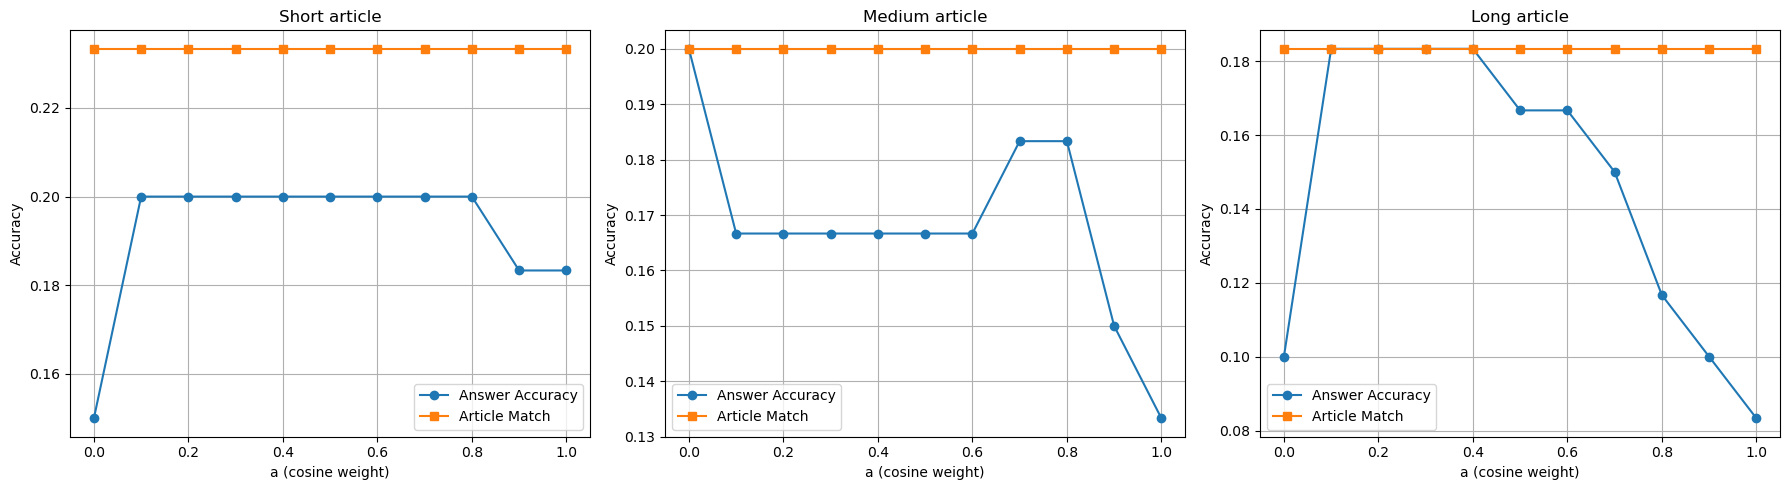

In [ ]:
#wykres accuracies - analogicznie
spacy_final = [spacy_sho, spacy_med, spacy_lon]  
labels = ['Short', 'Medium', 'Long']    

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  

for i in range(len(spacy_final)):
    acc_ans = [x[0] for x in spacy_final[i]]  
    acc_art = [x[1] for x in spacy_final[i]]  

    ax = axes[i] 

    ax.plot(a_list, acc_ans, label="Answer Accuracy", marker='o')
    ax.plot(a_list, acc_art, label="Article Match", marker='s')

    ax.set_title(f"{labels[i]} article")    
    ax.set_xlabel("a (cosine weight)")   
    ax.set_ylabel("Accuracy")                
    ax.grid(True)
    ax.legend()

plt.tight_layout()  
plt.savefig('spacy.png', dpi=300, bbox_inches='tight')
plt.show() 

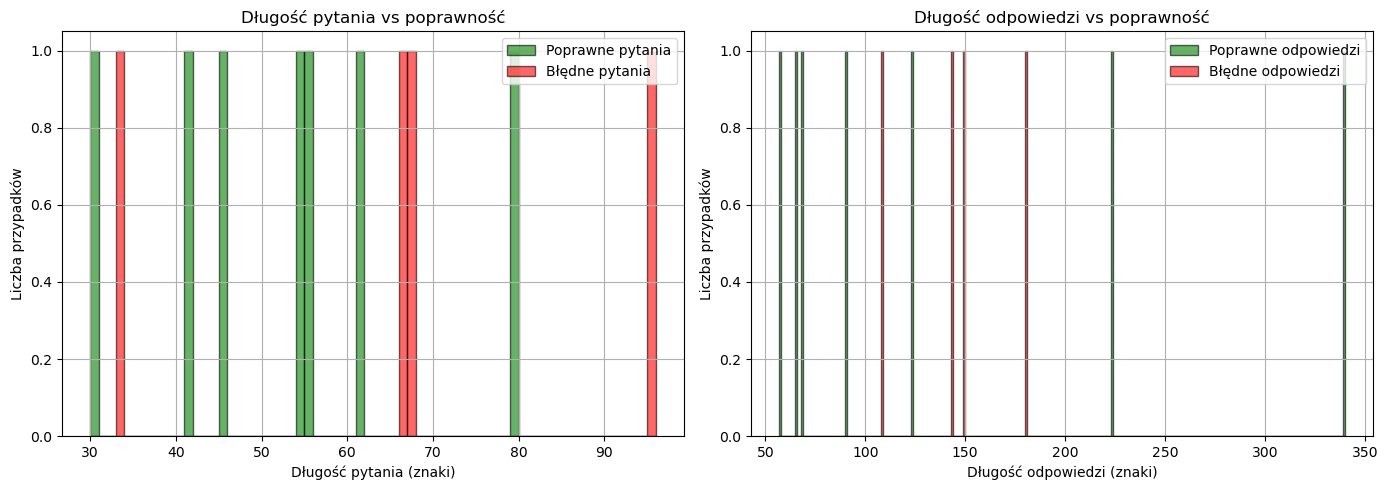

In [ ]:
#wykres długości pyt/odp - analogicznie
(acc_ans, acc_art, ok_len, notok_len) = run_model(con_lon, ques_lon, ans_lon, 0.1)

ok_ques = [q for (q,a) in ok_len]
notok_ques = [q for (q,a) in notok_len]
ques_len = ok_ques + notok_ques

ok_ans = [a for (q,a) in ok_len]
notok_ans = [a for (q,a) in notok_len]
ans_len = ok_ans + notok_ans

fig, axs = plt.subplots(1, 2, figsize=(14, 5))  # 1 rząd, 2 kolumny

# Wykres dla długości pytań
bins_q = range(min(ques_len), max(ques_len) + 1)
axs[0].hist(ok_ques, bins=bins_q, alpha=0.6, label="Poprawne pytania", color='green', edgecolor='black')
axs[0].hist(notok_ques, bins=bins_q, alpha=0.6, label="Błędne pytania", color='red', edgecolor='black')
axs[0].set_title("Długość pytania vs poprawność")
axs[0].set_xlabel("Długość pytania (znaki)")
axs[0].set_ylabel("Liczba przypadków")
axs[0].legend()
axs[0].grid(True)

# Wykres dla długości odpowiedzi
bins_a = range(min(ans_len), max(ans_len) + 1)
axs[1].hist(ok_ans, bins=bins_a, alpha=0.6, label="Poprawne odpowiedzi", color='green', edgecolor='black')
axs[1].hist(notok_ans, bins=bins_a, alpha=0.6, label="Błędne odpowiedzi", color='red', edgecolor='black')
axs[1].set_title("Długość odpowiedzi vs poprawność")
axs[1].set_xlabel("Długość odpowiedzi (znaki)")
axs[1].set_ylabel("Liczba przypadków")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

Spacy + filtracja artykułów z Set of Words

In [ ]:
#model spacy embeddings + set of words vectoriser

#preprocessing
def preprocess(text):
    doc = nlp(re.sub(r"[^\w\s]", "", text.lower())) #dopasuj wszytsko co nie jest literą bądź liczbą
    return " ".join([token.lemma_ for token in doc if not token.is_stop]) #lematyzacja tokenów, usunięcie stopwords

#n-gram overlap
def ngram_overlap(q, s, n=2): #q-question,  s-sentence
    q_ngrams = set(ngrams(q.split(), n)) #tworzenie setu ngramów
    s_ngrams = set(ngrams(s.split(), n))
    if not q_ngrams or not s_ngrams:
        return 0
    return len(q_ngrams & s_ngrams) / len(q_ngrams)  #długość części wspólnej / długość question

#score sentence - analogicznie
def score_sentence(question, sentence, vectorizer=None, a=0.9):
    question_proc = preprocess(question)
    sentence_proc = preprocess(sentence)

    # Używamy spacy embeddings
    question_vec = nlp(question_proc).vector
    sentence_vec = nlp(sentence_proc).vector

    if np.linalg.norm(question_vec) == 0 or np.linalg.norm(sentence_vec) == 0:
        cos_sim = 0
    else:
        cos_sim = cosine_similarity([question_vec], [sentence_vec])[0][0]

    ngram_sim = ngram_overlap(question_proc, sentence_proc, n=2)
    return a * cos_sim + (1 - a) * ngram_sim

#train model - analogicznie
def train_model(contexts, vectorizer):
    all_sentences = []
    processed_articles = []

    for article in contexts:
        sentences = [sent.text.strip() for sent in nlp(article).sents] #lista zdan z artykułu - zdania bez białych znaków na koncach lini
        all_sentences.append(sentences)
        processed_articles.append(preprocess(article))

    vectorizer.fit(processed_articles) #preproccesing i nauka vectoriser na context
    return all_sentences, processed_articles

#select best article - set of words
def select_best_article(question, processed_articles, vectorizer):
    question_proc = preprocess(question)
    
    matrix = normalize(vectorizer.transform([question_proc] + processed_articles))
    sims = cosine_similarity(matrix[0], matrix[1:])[0] #podobieństwo wektorowe
    return int(np.argmax(sims))

# ask question
def ask_question(question, all_sentences, processed_articles, vectorizer, a: float):
    best_article_idx = select_best_article(question, processed_articles, vectorizer)
    candidate_sentences = all_sentences[best_article_idx]
    scores = [score_sentence(question, s, vectorizer, a) for s in candidate_sentences]
    best_idx = int(np.argmax(scores))
    return candidate_sentences[best_idx]

# similarity check
def is_similar(pred, true, vectorizer=None, threshold=0.8):
    pred_proc = preprocess(pred)
    true_proc = preprocess(true)

    pred_vec = nlp(pred_proc).vector
    true_vec = nlp(true_proc).vector

    if np.linalg.norm(pred_vec) == 0 or np.linalg.norm(true_vec) == 0:
        similarity = 0
    else:
        similarity = cosine_similarity([pred_vec], [true_vec])[0][0]

    return similarity >= threshold


def run_model(vectorizer, context, questions, answers, a: float):
    all_sentences, processed_articles = train_model(context, vectorizer)

    ans_score = 0
    art_score = 0
    ok_len = []
    notok_len = []

    for i in range(len(questions)):
        best_article_idx = select_best_article(questions[i], processed_articles, vectorizer)
        candidate_sentences = all_sentences[best_article_idx]

        article_correct = answers[i] in candidate_sentences
        art_score += int(article_correct)

        pred_ans = ask_question(questions[i], all_sentences, processed_articles, vectorizer, a)
        answer_correct = is_similar(pred_ans, answers[i], vectorizer, 0.9)
        ans_score += int(answer_correct)

        if article_correct:
            q_len = len(questions[i])
            a_len = len(answers[i])
            if answer_correct:
                ok_len.append((q_len, a_len))
            else:
                notok_len.append((q_len, a_len))

    acc_ans = ans_score / len(questions)
    acc_art = art_score / len(questions)

    return (acc_ans, acc_art, ok_len, notok_len)

In [13]:
#spaCy + set of words vectoriser
spavec_sho, spavec_med, spavec_lon = [], [], []

for a in a_list:
    (acc_ans, acc_art, ok_len, notok_len) = run_model(CountVectorizer(binary=True), con_sho, ques_sho, ans_sho, a)
    spavec_sho.append((acc_ans, acc_art))
    (acc_ans, acc_art, ok_len, notok_len) = run_model(CountVectorizer(binary=True), con_med, ques_med, ans_med, a)
    spavec_med.append((acc_ans, acc_art))
    (acc_ans, acc_art, ok_len, notok_len) = run_model(CountVectorizer(binary=True), con_lon, ques_lon, ans_lon, a)
    spavec_lon.append((acc_ans, acc_art))

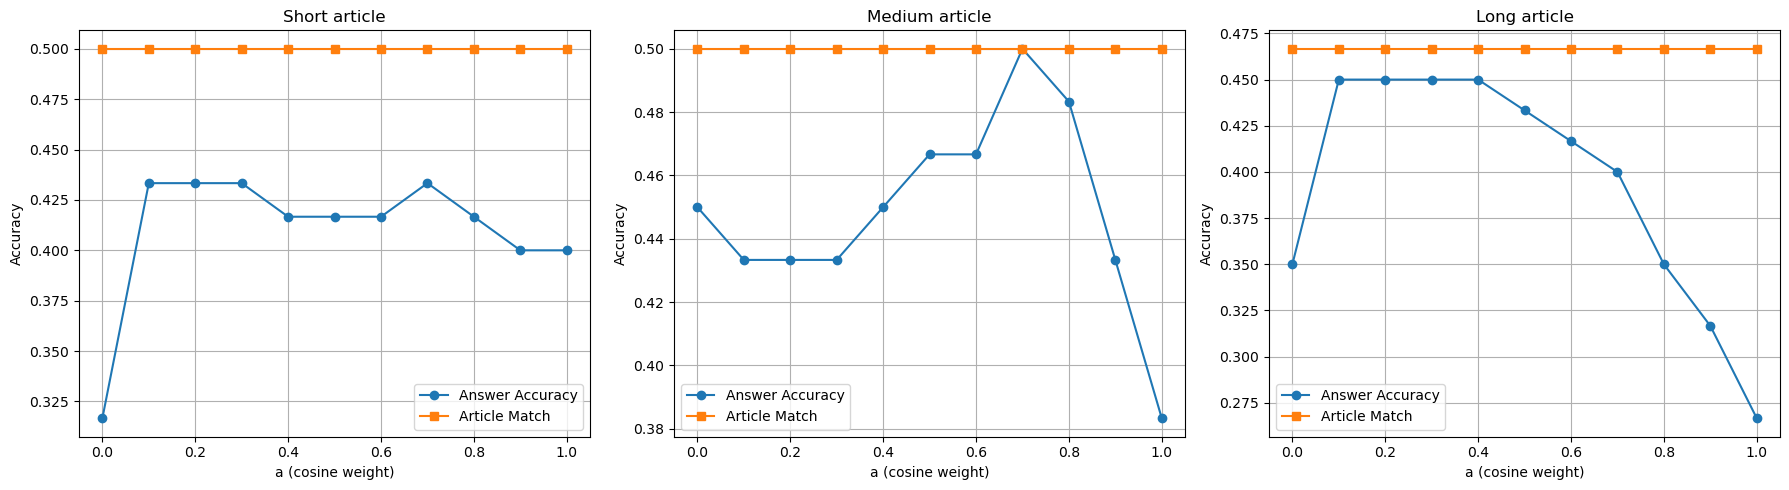

In [ ]:
#wykres accuracies
spavec_final = [spavec_sho, spavec_med, spavec_lon]  
labels = ['Short', 'Medium', 'Long']    

fig, axes = plt.subplots(1, 3, figsize=(18, 5))  

for i in range(len(spavec_final)):
    acc_ans = [x[0] for x in spavec_final[i]]  
    acc_art = [x[1] for x in spavec_final[i]]  

    ax = axes[i]  # aktualna oś (subplot)

    ax.plot(a_list, acc_ans, label="Answer Accuracy", marker='o')
    ax.plot(a_list, acc_art, label="Article Match", marker='s')

    ax.set_title(f"{labels[i]} article")    
    ax.set_xlabel("a (cosine weight)")   
    ax.set_ylabel("Accuracy")                
    ax.grid(True)
    ax.legend()

plt.tight_layout() 
plt.savefig('spavec.png', dpi=300, bbox_inches='tight') 
plt.show() 

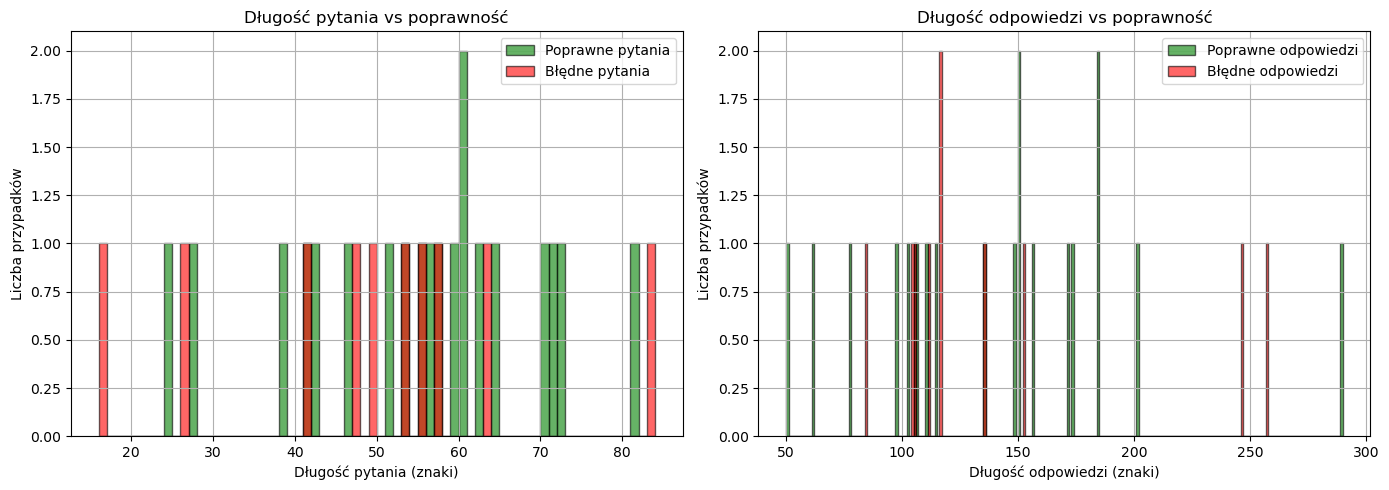

In [ ]:
#wykres długości pyt/odp dla najlepszego modleu
(acc_ans, acc_art, ok_len, notok_len) = run_model(CountVectorizer(binary=True), con_med, ques_med, ans_med, 0.7)

ok_ques = [q for (q,a) in ok_len]
notok_ques = [q for (q,a) in notok_len]
ques_len = ok_ques + notok_ques

ok_ans = [a for (q,a) in ok_len]
notok_ans = [a for (q,a) in notok_len]
ans_len = ok_ans + notok_ans

fig, axs = plt.subplots(1, 2, figsize=(14, 5))  

#długość pytań
bins_q = range(min(ques_len), max(ques_len) + 1)
axs[0].hist(ok_ques, bins=bins_q, alpha=0.6, label="Poprawne pytania", color='green', edgecolor='black')
axs[0].hist(notok_ques, bins=bins_q, alpha=0.6, label="Błędne pytania", color='red', edgecolor='black')
axs[0].set_title("Długość pytania vs poprawność")
axs[0].set_xlabel("Długość pytania (znaki)")
axs[0].set_ylabel("Liczba przypadków")
axs[0].legend()
axs[0].grid(True)

#długość odpowiedzi
bins_a = range(min(ans_len), max(ans_len) + 1)
axs[1].hist(ok_ans, bins=bins_a, alpha=0.6, label="Poprawne odpowiedzi", color='green', edgecolor='black')
axs[1].hist(notok_ans, bins=bins_a, alpha=0.6, label="Błędne odpowiedzi", color='red', edgecolor='black')
axs[1].set_title("Długość odpowiedzi vs poprawność")
axs[1].set_xlabel("Długość odpowiedzi (znaki)")
axs[1].set_ylabel("Liczba przypadków")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()

Sentence Transformers - SBERT

In [ ]:
#załadowanie modelu
sbert_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-mpnet-base-v2")

Pytanie wybierane z najlepszego chunka

In [ ]:
#preprocessing
def preprocess(text, preprocess_enabled=True):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    if preprocess_enabled: #do sprawdzenia czy wycinanie stopwords/ lematyzacja pomaga
        doc = nlp(text)
        return " ".join([token.lemma_ for token in doc if not token.is_stop])
    else:
        return text

#chunking - dzielenie artykułu na segmenty (sliding window)
def chunk_article(article, chunk_size, stride): #stride - co ile przesunięcie
    words = article.split() #lista słów dzielona po białych znakach
    chunks = []
    for i in range(0, len(words), stride): #przesuwamy co stride
        chunk = words[i:i+chunk_size] #długośc chunka
        if len(chunk) < max(20, chunk_size * 0.1): #minimalna długość fragmentu: 10% chunka lub 20 słów
            continue
        chunks.append(" ".join(chunk))
        if i + chunk_size >= len(words):
            break
    return chunks

#train model - batch encode wszystkich chunków dla większej wydajności
def train_model(contexts, chunk_size, stride, preprocess_enabled=True):
    all_chunks = []
    chunk_article_map = []
    chunks_for_encoding = []

    #zbieranie chunków z artykułów
    for idx, article in enumerate(contexts): #iteracja po artykułach
        chunks = chunk_article(article, chunk_size=chunk_size, stride=stride) #generowanie chunków
        all_chunks.append(chunks)
        chunk_article_map.extend([idx] * len(chunks)) #mapa chunk - artykuł
        chunks_for_encoding.extend([preprocess(c, preprocess_enabled) for c in chunks]) #lista oczyszczonych chunków   

    #batch encode wszystkich chunków na raz
    chunk_embeddings = sbert_model.encode(chunks_for_encoding, convert_to_tensor=True) #chunki na tensor (wszytskie na raz)

    return all_chunks, chunk_embeddings, chunk_article_map

# predykcja odpoweidzi - najlepsze chunki
def ask_question_best_chunk(question, all_chunks, chunk_embeddings, chunk_article_map, top_k=10, preprocess_enabled=True):
    q_embed = sbert_model.encode(preprocess(question, preprocess_enabled), convert_to_tensor=True) #pytanie na tensor
    sims = util.pytorch_cos_sim(q_embed, chunk_embeddings)[0] #podobieństwo cosinusowe jako tensor

    top_k = min(top_k, len(sims)) #top 5 chunków
    top_k_indices = torch.topk(sims, k=top_k).indices.cpu().tolist() #indeksy chunków o największym podobieństwie, tensor  na liste liczb

    best_idx = top_k_indices[0] #najlepszy chunk

    best_article_idx = chunk_article_map[best_idx] #z którego artykułu

    #indeks lokalny chunku
    count_before = 0
    for i in range(best_idx):
        if chunk_article_map[i] == best_article_idx:
            count_before += 1

    best_chunk = all_chunks[best_article_idx][count_before] #najlepszy chunk

    return best_chunk, best_article_idx

#predykcja odpoweidzi - najlepsze zdanie z chunka
def ask_question_best_sentence(question, all_chunks, chunk_embeddings, chunk_article_map, top_k=10, preprocess_enabled=True):
    best_chunk, best_article_idx = ask_question_best_chunk(question, all_chunks, chunk_embeddings, chunk_article_map, top_k, preprocess_enabled)
    
    #podziel chunka na zdania (prosty split po kropkach)
    sentences = [s.strip() for s in re.split(r'(?<=[.!?]) +', best_chunk) if s.strip()]
    if not sentences:
        return "", best_article_idx
  
    q_embed = sbert_model.encode(preprocess(question, preprocess_enabled), convert_to_tensor=True)
    sent_embeddings = sbert_model.encode([preprocess(s, preprocess_enabled) for s in sentences], convert_to_tensor=True)
    
    #poodbienstwo do pytania
    sims = util.pytorch_cos_sim(q_embed, sent_embeddings)[0]
    
    best_sent_idx = torch.argmax(sims).item()
    best_sentence = sentences[best_sent_idx]
    
    return best_sentence, best_article_idx

#similarity check
def is_similar(pred, true, threshold=0.9, preprocess_enabled=True):
    emb1 = sbert_model.encode(preprocess(pred, preprocess_enabled), convert_to_tensor=True)
    emb2 = sbert_model.encode(preprocess(true, preprocess_enabled), convert_to_tensor=True)
    sim = util.pytorch_cos_sim(emb1, emb2).item()
    return sim >= threshold

#chunk_score - czy odpowiedź w chunku lub podobna
def chunk_score(answer, chunk, threshold=0.7, preprocess_enabled=True):
    #czy odpowiedz w chunku
    if answer.lower() in chunk.lower():
        return 1.0
    #czy podobna
    emb_answer = sbert_model.encode(preprocess(answer, preprocess_enabled), convert_to_tensor=True)
    emb_chunk = sbert_model.encode(preprocess(chunk, preprocess_enabled), convert_to_tensor=True)
    sim = util.pytorch_cos_sim(emb_answer, emb_chunk).item()
    return sim if sim >= threshold else 0.0

#wywołanie
def run_model(contexts, questions, answers, chunk_size=150, stride=75, preprocess_enabled=True):
    all_chunks, chunk_embeddings, chunk_article_map = train_model(
        contexts, chunk_size=chunk_size, stride=stride, preprocess_enabled=preprocess_enabled
    )

    ans_score = 0
    art_score = 0
    ok_len = []
    notok_len = []

    for i in range(len(questions)): #pętla po pytaniach
        #znajdz najlepszy chunk
        best_chunk, pred_article_idx = ask_question_best_chunk(questions[i], all_chunks, chunk_embeddings, chunk_article_map, preprocess_enabled=preprocess_enabled)
        
        #znajdź najlepsze zdanie w najlepszym chunku
        best_sentence, _ = ask_question_best_sentence(
            questions[i], all_chunks, chunk_embeddings, chunk_article_map, preprocess_enabled=preprocess_enabled
        )

        #czy opowiedz jest w dobrym artykule
        article_correct = answers[i] in " ".join(all_chunks[pred_article_idx])
        art_score += int(article_correct)

        #czy odpowiedź jest faktycznie w najlepszym chunka (chunk_score)
        chu_score = chunk_score(answers[i], best_chunk, preprocess_enabled=preprocess_enabled)

        # Czy odpowiedź jest podobna?
        answer_correct = is_similar(best_sentence, preprocess(answers[i]), preprocess_enabled=preprocess_enabled)

        ans_score += int(answer_correct)

        q_len = len(questions[i])
        a_len = len(answers[i])
        if answer_correct:
            ok_len.append((q_len, a_len))
        else:
            notok_len.append((q_len, a_len))

    acc_ans = ans_score / len(questions)
    acc_chu = chu_score / len(questions)
    acc_art = art_score / len(questions)

    return acc_ans, acc_chu, acc_art, ok_len, notok_len

In [18]:
acc_ans, acc_chu, acc_art, ok_len, notok_len = run_model(con_sho, ques_sho, ans_sho, 300, 150, preprocess_enabled=True)
print(acc_ans, acc_chu, acc_art)

0.23333333333333334 0.016666666666666666 0.5


In [19]:
acc_ans, acc_chu, acc_art, ok_len, notok_len = run_model(con_med, ques_med, ans_med, 300, 150, preprocess_enabled=True)
print(acc_ans, acc_chu, acc_art)

0.18333333333333332 0.016666666666666666 0.5166666666666667


In [20]:
acc_ans, acc_chu, acc_art, ok_len, notok_len = run_model(con_lon, ques_lon, ans_lon, 300, 150, preprocess_enabled=True)
print(acc_ans, acc_chu, acc_art)

0.15 0.0 0.45


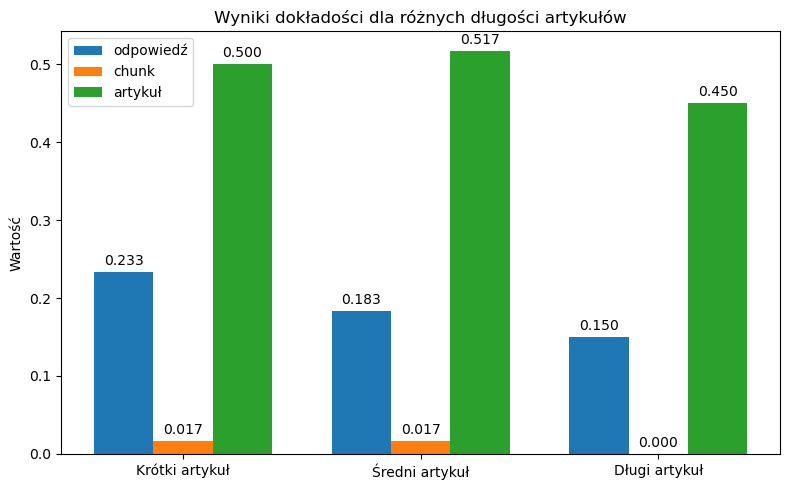

In [ ]:
#wykrs dokładności
labels = ['Krótki artykuł', 'Średni artykuł', 'Długi artykuł']
acc_ans = [0.2333, 0.1833, 0.15]
acc_chu = [0.0167, 0.0167, 0.0]
acc_art = [0.5, 0.5167, 0.45]

x = np.arange(len(labels))  
width = 0.25  

fig, ax = plt.subplots(figsize=(8,5))

rects1 = ax.bar(x - width, acc_ans, width, label='odpowiedź', color='tab:blue')
rects2 = ax.bar(x, acc_chu, width, label='chunk', color='tab:orange')
rects3 = ax.bar(x + width, acc_art, width, label='artykuł', color='tab:green')

ax.set_ylabel('Wartość')
ax.set_title('Wyniki dokładości dla różnych długości artykułów')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()

Pytanie wybieranie z k najlepszych chunków

In [23]:
#preprocessing
def preprocess(text, preprocess_enabled=True):
    text = text.lower()
    text = re.sub(r"[^\w\s]", "", text)
    if preprocess_enabled: #do sprawdzenia czy wycinanie stopwords/ lematyzacja pomaga
        doc = nlp(text)
        return " ".join([token.lemma_ for token in doc if not token.is_stop])
    else:
        return text

#chunking - dzielenie artykułu na segmenty (sliding window)
def chunk_article(article, chunk_size, stride): #stride - co ile przesunięcie
    words = article.split() #lista słów dzielona po białych znakach
    chunks = []
    for i in range(0, len(words), stride): #przesuwamy co stride
        chunk = words[i:i+chunk_size] #długośc chunka
        if len(chunk) < max(20, chunk_size * 0.1): #minimalna długość fragmentu: 10% chunka lub 20 słów
            continue
        chunks.append(" ".join(chunk))
        if i + chunk_size >= len(words):
            break
    return chunks

#train model - batch encode wszystkich chunków dla większej wydajności
def train_model(contexts, chunk_size, stride, preprocess_enabled=True):
    all_chunks = []
    chunk_article_map = []
    chunks_for_encoding = []

    #zbieranie chunków z artykułów
    for idx, article in enumerate(contexts): #iteracja po artykułach
        chunks = chunk_article(article, chunk_size=chunk_size, stride=stride) #generowanie chunków
        all_chunks.append(chunks)
        chunk_article_map.extend([idx] * len(chunks)) #mapa chunk - artykuł
        chunks_for_encoding.extend([preprocess(c, preprocess_enabled) for c in chunks]) #lista oczyszczonych chunków   

    #batch encode wszystkich chunków na raz
    chunk_embeddings = sbert_model.encode(chunks_for_encoding, convert_to_tensor=True) #chunki na tensor (wszytskie na raz)

    return all_chunks, chunk_embeddings, chunk_article_map

# predykcja odpoweidzi - najlepsze chunki
def ask_question_top_k_chunks(question, all_chunks, chunk_embeddings, chunk_article_map, top_k=10, preprocess_enabled=True):
    q_embed = sbert_model.encode(preprocess(question, preprocess_enabled), convert_to_tensor=True)
    sims = util.pytorch_cos_sim(q_embed, chunk_embeddings)[0]
    
    top_k = min(top_k, len(sims))
    top_k_indices = torch.topk(sims, k=top_k).indices.cpu().tolist()
    
    chunks_and_articles = []
    for idx in top_k_indices:
        article_idx = chunk_article_map[idx]
        # lokalny indeks chunku w artykule
        count_before = sum(1 for i in range(idx) if chunk_article_map[i] == article_idx)
        chunk_text = all_chunks[article_idx][count_before]
        chunks_and_articles.append((chunk_text, article_idx))
    
    return chunks_and_articles

# Szuka najlepsze zdanie spośród top_k chunków
def ask_question_best_sentence_top_k(question, all_chunks, chunk_embeddings, chunk_article_map, top_k=10, preprocess_enabled=True):
    chunks_and_articles = ask_question_top_k_chunks(question, all_chunks, chunk_embeddings, chunk_article_map, top_k, preprocess_enabled)
    
    q_embed = sbert_model.encode(preprocess(question, preprocess_enabled), convert_to_tensor=True)
    
    best_sentence = ""
    best_article_idx = -1
    best_sim = -1.0
    
    for chunk_text, article_idx in chunks_and_articles:
        sentences = [s.strip() for s in re.split(r'(?<=[.!?]) +', chunk_text) if s.strip()]
        if not sentences:
            continue
        
        sent_embeddings = sbert_model.encode([preprocess(s, preprocess_enabled) for s in sentences], convert_to_tensor=True)
        sims = util.pytorch_cos_sim(q_embed, sent_embeddings)[0]
        
        max_sim_idx = torch.argmax(sims).item()
        max_sim_val = sims[max_sim_idx].item()
        
        if max_sim_val > best_sim:
            best_sim = max_sim_val
            best_sentence = sentences[max_sim_idx]
            best_article_idx = article_idx
    
    return best_sentence, best_article_idx

#similarity check
def is_similar(pred, true, threshold=0.9, preprocess_enabled=True):
    emb1 = sbert_model.encode(preprocess(pred, preprocess_enabled), convert_to_tensor=True)
    emb2 = sbert_model.encode(preprocess(true, preprocess_enabled), convert_to_tensor=True)
    sim = util.pytorch_cos_sim(emb1, emb2).item()
    return sim >= threshold

#chunk_score - czy odpowiedź w chunku lub podobna
def chunk_score(answer, chunk, threshold=0.7, preprocess_enabled=True):
    #czy odpowiedz w chunku
    if answer.lower() in chunk.lower():
        return 1.0
    #czy podobna
    emb_answer = sbert_model.encode(preprocess(answer, preprocess_enabled), convert_to_tensor=True)
    emb_chunk = sbert_model.encode(preprocess(chunk, preprocess_enabled), convert_to_tensor=True)
    sim = util.pytorch_cos_sim(emb_answer, emb_chunk).item()
    return sim if sim >= threshold else 0.0

#wywołanie
def run_model(contexts, questions, answers, chunk_size=150, stride=75, preprocess_enabled=True, top_k=10):
    all_chunks, chunk_embeddings, chunk_article_map = train_model(
        contexts, chunk_size=chunk_size, stride=stride, preprocess_enabled=preprocess_enabled
    )

    ans_score = 0
    art_score = 0
    chu_score = 0  # inicjalizacja sumy chunk_score
    ok_len = []
    notok_len = []

    for i in range(len(questions)):
        best_sentence, pred_article_idx = ask_question_best_sentence_top_k(
            questions[i], all_chunks, chunk_embeddings, chunk_article_map, top_k=top_k, preprocess_enabled=preprocess_enabled
        )

        # Pobierz top_k chunków, żeby znaleźć najlepszy chunk zawierający najlepsze zdanie
        top_chunks = ask_question_top_k_chunks(
            questions[i], all_chunks, chunk_embeddings, chunk_article_map, top_k=top_k, preprocess_enabled=preprocess_enabled
        )

        # Znajdź chunk zawierający best_sentence (pierwszy, w którym jest best_sentence)
        best_chunk = ""
        for chunk_text, article_idx in top_chunks:
            if best_sentence in chunk_text:
                best_chunk = chunk_text
                break
        if not best_chunk:
            # fallback - jeśli nie znaleziono, to weź pierwszy chunk z top_chunks
            best_chunk = top_chunks[0][0]

        # czy odpowiedź jest w dobrym artykule
        article_correct = answers[i] in " ".join(all_chunks[pred_article_idx])
        art_score += int(article_correct)

        # chunk_score akumulujemy
        chu_score += chunk_score(answers[i], best_chunk, preprocess_enabled=preprocess_enabled)

        # is_similar samo preprocessuje argumenty
        answer_correct = is_similar(best_sentence, answers[i], preprocess_enabled=preprocess_enabled)
        ans_score += int(answer_correct)

        q_len = len(questions[i])
        a_len = len(answers[i])
        if answer_correct:
            ok_len.append((q_len, a_len))
        else:
            notok_len.append((q_len, a_len))

    acc_ans = ans_score / len(questions)
    acc_chu = chu_score / len(questions)
    acc_art = art_score / len(questions)

    return acc_ans, acc_chu, acc_art, ok_len, notok_len


In [24]:
acc_ans, acc_chu, acc_art, ok_len, notok_len = run_model(con_sho, ques_sho, ans_sho, 300, 150, preprocess_enabled=True)
print(acc_ans, acc_chu, acc_art)

0.18333333333333332 0.5955121924479803 0.4166666666666667


In [25]:
acc_ans, acc_chu, acc_art, ok_len, notok_len = run_model(con_med, ques_med, ans_med, 300, 150, preprocess_enabled=True)
print(acc_ans, acc_chu, acc_art)

0.15 0.6593354990084966 0.5666666666666667


In [26]:
acc_ans, acc_chu, acc_art, ok_len, notok_len = run_model(con_lon, ques_lon, ans_lon, 300, 150, preprocess_enabled=True)
print(acc_ans, acc_chu, acc_art)

0.18333333333333332 0.42540635069211324 0.5


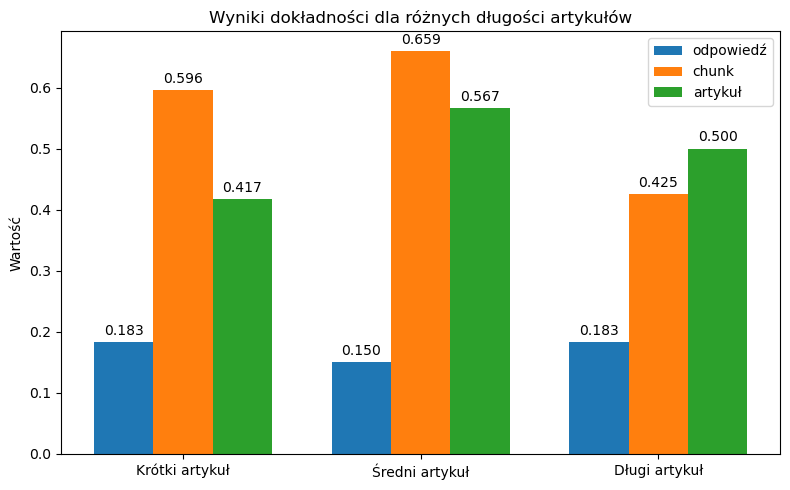

In [ ]:
#wykres dokładości

labels = ['Krótki artykuł', 'Średni artykuł', 'Długi artykuł']
acc_ans = [0.1833, 0.15, 0.1833]
acc_chu = [0.5955, 0.6593, 0.4254]
acc_art = [0.4167, 0.5667, 0.5]

x = np.arange(len(labels))  
width = 0.25

fig, ax = plt.subplots(figsize=(8,5))

rects1 = ax.bar(x - width, acc_ans, width, label='odpowiedź', color='tab:blue')
rects2 = ax.bar(x, acc_chu, width, label='chunk', color='tab:orange')
rects3 = ax.bar(x + width, acc_art, width, label='artykuł', color='tab:green')

ax.set_ylabel('Wartość')
ax.set_title('Wyniki dokładności dla różnych długości artykułów')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.tight_layout()
plt.show()
